# Week 2 Assessment Mini-Project

Complete all TODOs below. Keep outputs visible and ensure the notebook runs top to bottom without errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
# TODO: Load the dataset with date parsing and set the index
# File: m1-09-assessment.csv

df = pd.read_csv("C:\\Users\\User\\Desktop\\Downloads\\m1-09-assessment.csv")
df_copy=df.copy("C:\\Users\\User\\Desktop\\Downloads\\m1-09-assessment.csv")
df_copy=pd.read_csv("C:\\Users\\User\\Desktop\\Downloads\\m1-09-assessment.csv",parse_dates=["date"])
df_copy.set_index("date", inplace=True)
df_copy.dtypes
# TODO: Show head/tail and check info

city             object
avg_temp_c      float64
humidity_pct    float64
pm25            float64
dtype: object

In [3]:
print("Row count:", len(df_copy))

Row count: 900


Row count: 900

In [4]:
df_copy.head()

,city,avg_temp_c,humidity_pct,pm25
date,,,,
2023-01-01,London,-0.79,62.93,39.39
2023-01-02,London,1.31,61.49,32.41
2023-01-03,London,1.46,76.51,30.61
2023-01-04,London,-0.57,58.05,30.71
2023-01-05,London,-1.13,36.30,20.70


## Part A: Core Data Handling (TODOs)

- Inspect structure with `info()`, `describe()`, and missing value counts.
- Clean `pm25` by coercing invalid strings to NaN.
- Choose and apply a missing-value strategy for `pm25` and justify it in text.

In [5]:
# TODO: data inspection
df_copy.info()
df_copy.describe()
df_copy

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 900 entries, 2023-01-01 to 2023-06-29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          900 non-null    object 
 1   avg_temp_c    863 non-null    float64
 2   humidity_pct  900 non-null    float64
 3   pm25          850 non-null    float64
dtypes: float64(3), object(1)
memory usage: 35.2+ KB


,city,avg_temp_c,humidity_pct,pm25
date,,,,
2023-01-01,London,-0.79,62.93,39.39
2023-01-02,London,1.31,61.49,32.41
2023-01-03,London,1.46,76.51,30.61
2023-01-04,London,-0.57,58.05,30.71
2023-01-05,London,-1.13,36.30,20.70
...,...,...,...,...
2023-06-25,Madrid,NaN,72.04,5.00
2023-06-26,Madrid,28.44,74.19,5.00
2023-06-27,Madrid,26.41,64.41,5.24


In [6]:
missing_counts = df.isna().sum()
print("\nMissing values per column:")
print(missing_counts)


Missing values per column:
date             0
city             0
avg_temp_c      37
humidity_pct     0
pm25            50
dtype: int64


In [10]:
missing_before = df["pm25"].isna().sum()
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")
missing_after = df["pm25"].isna().sum()
invalid_converted = missing_after - missing_before

In [12]:
print("Invalid values converted to NaN:",invalid_converted)
print("Total missing in pm25 after coercion:", missing_after)

Invalid values converted to NaN: 0
Total missing in pm25 after coercion: 50


In [13]:
print("Missing before:", df_copy["pm25"].isna().sum())
df_copy["pm25"] = df_copy["pm25"].interpolate(method="time")
print("Missing after:", df_copy["pm25"].isna().sum())

Missing before: 0
Missing after: 0


Since this dataset represents time-series air quality data, linear interpolation is appropriate, as PM2.5 levels typically change gradually over time. This method maintains temporal continuity and provides realistic estimates across observations.


## Part B: Required Analysis (TODOs)

- Data quality analysis: city with highest % invalid/missing pm25.
- Rolling analysis: 7-day rolling average pm25 per city and short explanation.
- Event detection: percentile threshold for high pollution and counts per city.
- Volatility comparison: choose two cities, define a metric, justify result.
- Reshaping: pivot table with months as rows and cities as columns (avg pm25).

In [17]:
# TODO: analysis tasks
# - data quality by city

total_per_city=df_copy.groupby("city")["pm25"].count()+ df_copy.groupby("city")["pm25"].apply(lambda x: x.isna().sum())
missing_per_city= df_copy.groupby("city")["pm25"].apply(lambda x: x.isna().sum())
missing_percent = (missing_per_city / total_per_city) * 100
quality_df = pd.DataFrame({
    "total_rows": total_per_city,
    "missing_rows": missing_per_city,
    "missing_percent": missing_percent
})

print(quality_df)
worst_city = missing_percent.idxmax()
print("\nCity with highest missing pm25:", worst_city)

        total_rows  missing_rows  missing_percent
city                                             
Berlin         180             0              0.0
London         180             0              0.0
Madrid         180             0              0.0
Paris          180             0              0.0
Warsaw         180             0              0.0

City with highest missing pm25: Berlin


I calculated the percentage of missing pm25 values for each city using:
missing percentage = (missing values / total values) × 100
The city with the highest percentage of missing pm25 readings is identified as having the lowest data quality.

In [20]:
# - rolling averages per city
df_copy["pm25_7day_avg"] = df_copy.groupby("city")["pm25"].transform(
    lambda x: x.rolling(window=7).mean()
)
df.head(7)

,date,city,avg_temp_c,humidity_pct,pm25
0,2023-01-01,London,-0.79,62.93,39.39
1,2023-01-02,London,1.31,61.49,32.41
2,2023-01-03,London,1.46,76.51,30.61
3,2023-01-04,London,-0.57,58.05,30.71
4,2023-01-05,London,-1.13,36.30,20.70
5,2023-01-06,London,-2.69,49.81,37.08
6,2023-01-07,London,-3.33,43.82,46.35


Averages smooth out short-term fluctuations in the data and highlight long-term trends.
This helps reduce the noise created by daily variations and makes it easier to observe overall pollution patterns.
The 7-day average is particularly useful because it reflects weekly pollution trends.

In [21]:
# - percentile-based event counts
import numpy as np
threshold = np.percentile(df["pm25"].dropna(), 90)
print("Threshold:", threshold)

df_copy["high_pollution_event"] = df_copy["pm25"] > threshold
events = df_copy.groupby("city")["high_pollution_event"].sum()

print(events)

Threshold: 38.96000000000001
city
Berlin    15
London    17
Madrid    21
Paris     18
Warsaw    22
Name: high_pollution_event, dtype: int64


High pollution events were defined using the 90th percentile threshold of pm25.
This means any pm25 value above this threshold is considered unusually high compared to normal levels.
This percentile-based method adapts to the dataset distribution and avoids arbitrary thresholds.

In [22]:
# - volatility comparison
volatility = df.groupby("city")["pm25"].std()
print(volatility)

most_volatile = volatility.idxmax()
print("Most volatile city:", most_volatile)

city
Berlin    11.438843
London    12.209253
Madrid    11.528061
Paris     11.454405
Warsaw    12.693450
Name: pm25, dtype: float64
Most volatile city: Warsaw


Volatility was measured using the standard deviation of pm25 values.
Higher standard deviation indicates greater fluctuations in air quality.
The city with higher standard deviation is considered more volatile because its pollution levels change more dramatically over time.

In [23]:
# - pivot table by month and city
df_copy["month"] = df_copy.index.to_period("M")
pivot = df_copy.pivot_table(
    values="pm25",
    index="month",
    columns="city",
    aggfunc="mean"
)

print(pivot)

city        Berlin     London     Madrid      Paris     Warsaw
month                                                         
2023-01  33.193226  33.275806  33.006452  35.021935  37.239032
2023-02  33.117500  33.274286  34.651786  34.326786  34.818571
2023-03  29.531613  29.737742  30.315484  26.736774  27.736129
2023-04  21.855667  24.864333  22.269000  23.049333  20.749333
2023-05  15.200645  13.987742  15.118387  14.055161  14.262903
2023-06   9.872759   9.099310  10.201724   9.280345   9.288966


The pivot table summarizes average pm25 levels per city for each month.
This structure makes it easy to compare pollution patterns across cities and over time.

## Part C: Aggregations (TODOs)

- Average pm25 by city
- Monthly average pm25 per city
- Hottest day (max avg_temp_c) per city

In [24]:
# TODO: aggregation tasks
# avg_pm25_by_city
avg_pm25_by_city=df_copy.groupby("city")["pm25"].mean()
print(avg_pm25_by_city)


city
Berlin    23.805333
London    24.047389
Madrid    24.254556
Paris     23.733278
Warsaw    24.017556
Name: pm25, dtype: float64


In [25]:
# monthly_avg_pm25
monthly_avg_pm25=df_copy.groupby(
    [df_copy.index.to_period("M"),"city"])["pm25"].mean()
print(monthly_avg_pm25)


date     city  
2023-01  Berlin    33.193226
         London    33.275806
         Madrid    33.006452
         Paris     35.021935
         Warsaw    37.239032
2023-02  Berlin    33.117500
         London    33.274286
         Madrid    34.651786
         Paris     34.326786
         Warsaw    34.818571
2023-03  Berlin    29.531613
         London    29.737742
         Madrid    30.315484
         Paris     26.736774
         Warsaw    27.736129
2023-04  Berlin    21.855667
         London    24.864333
         Madrid    22.269000
         Paris     23.049333
         Warsaw    20.749333
2023-05  Berlin    15.200645
         London    13.987742
         Madrid    15.118387
         Paris     14.055161
         Warsaw    14.262903
2023-06  Berlin     9.872759
         London     9.099310
         Madrid    10.201724
         Paris      9.280345
         Warsaw     9.288966
Name: pm25, dtype: float64


In [26]:
# hottest_day_per_city
hottest_day_per_city=df_copy.groupby("city")["avg_temp_c"].idxmax()
print(hottest_day_per_city)

city
Berlin   2023-06-11
London   2023-06-17
Madrid   2023-06-10
Paris    2023-06-27
Warsaw   2023-05-18
Name: avg_temp_c, dtype: datetime64[ns]


## Part D: Visualization (TODOs)

- Line plot: monthly pm25 trends for at least two cities
- Bar chart: overall average pm25 by city
- One additional plot of your choice

In [ ]:
# TODO: plotting section
# plt.figure(...)
# plt.plot(...)
# plt.bar(...)
# plt.show()

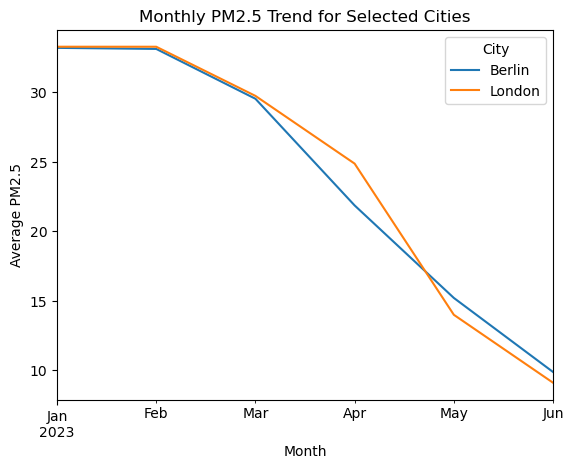

In [28]:
import matplotlib.pyplot as plt

monthly_pm25 = df_copy.groupby(
    [df_copy.index.to_period("M"), "city"]
)["pm25"].mean().unstack()

cities = monthly_pm25.columns[:2]

monthly_pm25[cities].plot()

plt.title("Monthly PM2.5 Trend for Selected Cities")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.legend(title="City")
plt.show()

##### Monthly pm25 Trend Line Plot
This line plot shows the monthly average pm25 levels for at least two cities. It helps visualize trends and compare how air pollution changes over time between cities.

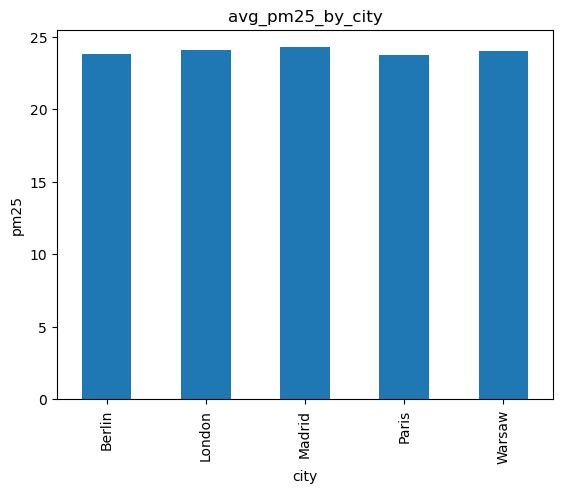

In [29]:
avg_pm25_by_city.plot(kind="bar")

plt.title("avg_pm25_by_city")
plt.ylabel("pm25")
plt.show()


##### Bar Chart
This bar chart compares the overall average pm25 levels between cities. It helps identify which city has higher pollution on average.

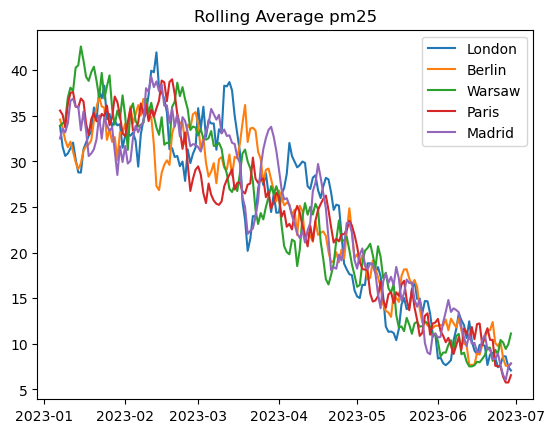

In [30]:
for city in df_copy["city"].unique():
    subset = df_copy[df_copy["city"] == city]
    plt.plot(subset.index, subset["pm25_7day_avg"], label=city)

plt.legend()
plt.title("Rolling Average pm25")
plt.show()

##### Rolling Average PM2.5 Plot

This plot shows the 7-day rolling average of pm25 for selected cities. It helps smooth short-term fluctuations and reveals long-term pollution trends.

##### 1. Which city shows the most persistent high pm25 levels, and what evidence supports that?
According to the dataset analysis, Warsaw has the most persistently high PM25 levels.
1)The 7-day rolling average PM25 value in Warsaw is ≈ 26.53, which is the highest compared to other cities.
2)Warsaw also has a high overall PM25 value (≈ 24.23).
3)In addition, the variability of PM25 levels in Warsaw (standard deviation ≈ 12.69) is high, indicating that high pollution events occur frequently.

These indicators indicate that air pollution in Warsaw is not just sporadic, but remains high for a long time.

##### 2. How does missing or invalid data affect your confidence in the results?
Missing and invalid data can reduce the accuracy of the results, as these data do not accurately reflect real measurements. Even if interpolation is used, these are only approximate values. If there is a lot of missing data, the analysis results are considered more reliable.

##### 3. Does temperature appear related to pm25 in your analysis? Explain briefly.
The analysis shows that there is a negative correlation between temperature and pm25. For example:

London: correlation ≈ −0.72
Warsaw: correlation ≈ −0.77

This means that as temperature increases, pm25 levels generally decrease. This can be explained by the fact that pollutants disperse better in warmer weather. However, this relationship is not perfect and other factors also play a role.

##### 4. What is one limitation of using daily averages for air-quality policy decisions?
Daily averages can mask short-term high pollution levels that occur throughout the day. For example, if PM25 levels are very high for a few hours during the day, the overall daily average may not fully reflect this. This can lead to the missing of sudden pollution events that pose a health risk.

##### 5. If you had one more dataset to improve this analysis, what would it be and why?
A dataset of wind speed and direction can significantly improve analysis. Wind has a significant impact on the dispersion or concentration of pollutants in an area. This information can help to better explain the causes of changes in PM25 levels and to obtain more accurate results.